# Linear Discriminant Analysis: A Comprehensive Guide

## 1. Introduction

This notebook covers the step-by-step implementation of **Linear Discriminant Analysis** in Python.

### Concept Overview
A supervised dimensionality reduction and classification method that projects features onto directions that maximize class separation.

### Mathematical Formula
The core mathematical relationship or objective is defined as:
$$
J(\mathbf{w}) = \frac{\mathbf{w}^T \mathbf{S}_B \mathbf{w}}{\mathbf{w}^T \mathbf{S}_W \mathbf{w}} \quad \text{where } \mathbf{S}_B \text{ is Between-Class Scatter, and } \mathbf{S}_W \text{ is Within-Class Scatter}
$$

### Real-World Analogy
**Analogy:** Rotating and viewing shadows of groups on a wall to find the angle where they overlap the least.

### Worked Example
**Worked Example:** Classifying 3 crop classes using N, P, K. LDA finds the projection direction where crop clusters overlap the least, maximizing separation, then performs classification.

## 2. Import Libraries

We import the standard data science and machine learning libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn import metrics
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Create Synthetic Dataset

We generate a realistic synthetic dataset to demonstrate the model's behavior and save it locally.

In [2]:
# Programmatic generation of agricultural crop features
from sklearn.datasets import make_classification
np.random.seed(42)
X_raw, y_raw = make_classification(n_samples=300, n_features=3, n_informative=3,
                                  n_redundant=0, n_classes=3, n_clusters_per_class=1,
                                  class_sep=1.5, random_state=42)
df = pd.DataFrame({
    'Nitrogen': np.round(X_raw[:, 0] * 15 + 50, 1),
    'Phosphorus': np.round(X_raw[:, 1] * 12 + 40, 1),
    'Potassium': np.round(X_raw[:, 2] * 10 + 30, 1),
    'CropType': y_raw
})
df.to_csv('dataset.csv', index=False)

## 4. Load & Inspect Dataset

We load the dataset using pandas to inspect the shape, variables, and summary statistics.

In [3]:
df = pd.read_csv('dataset.csv')
print('Dataset Shape:', df.shape)
df.info()
print(df.describe())

Dataset Shape: (300, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Nitrogen    300 non-null    float64
 1   Phosphorus  300 non-null    float64
 2   Potassium   300 non-null    float64
 3   CropType    300 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 9.5 KB
         Nitrogen  Phosphorus   Potassium    CropType
count  300.000000  300.000000  300.000000  300.000000
mean    26.843000   35.890000   34.737000    0.996667
std     14.986899   22.926276   16.929529    0.811697
min    -18.100000  -24.800000   -9.100000    0.000000
25%     18.075000   20.375000   21.350000    0.000000
50%     27.750000   31.900000   40.350000    1.000000
75%     36.025000   50.850000   47.425000    2.000000
max     72.200000  104.500000   65.800000    2.000000


## 5. Data Cleaning

Audit for missing values and duplicates.

In [4]:
print('Null values:\n', df.isnull().sum())
print('Duplicate count:', df.duplicated().sum())

Null values:
 Nitrogen      0
Phosphorus    0
Potassium     0
CropType      0
dtype: int64
Duplicate count: 0


## 6. Exploratory Data Analysis (EDA)

We visualize the distributions and correlations of features.

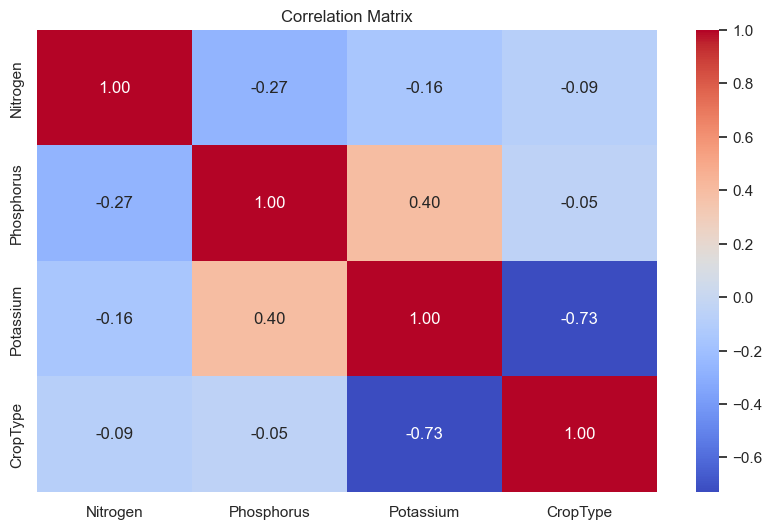

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 7. Feature Engineering & Scaling

Prepare the features and apply standardization if required.

In [6]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaling applied successfully.')

Scaling applied successfully.


## 8. Train-Test Split

Divide training and testing sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (210, 3), Test size: (90, 3)


## 9. Model Building

Instantiate and fit the model estimator.

In [8]:
model = LinearDiscriminantAnalysis(n_components=2)
model.fit(X_train, y_train)
print("LDA transformation model completed.")

LDA transformation model completed.


## 10. Prediction & 11. Model Evaluation

Check metrics to evaluate model performance.

In [9]:
y_pred = model.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Classification Report:\n", metrics.classification_report(y_test, y_pred))

Accuracy: 0.9222222222222223
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.78      0.88        27
           1       0.82      0.96      0.89        28
           2       0.97      1.00      0.99        35

    accuracy                           0.92        90
   macro avg       0.93      0.91      0.92        90
weighted avg       0.93      0.92      0.92        90



## 12. Visualizing Fit & Boundaries

Generate plots showing classification decision zones, regression lines, or clustering segments.

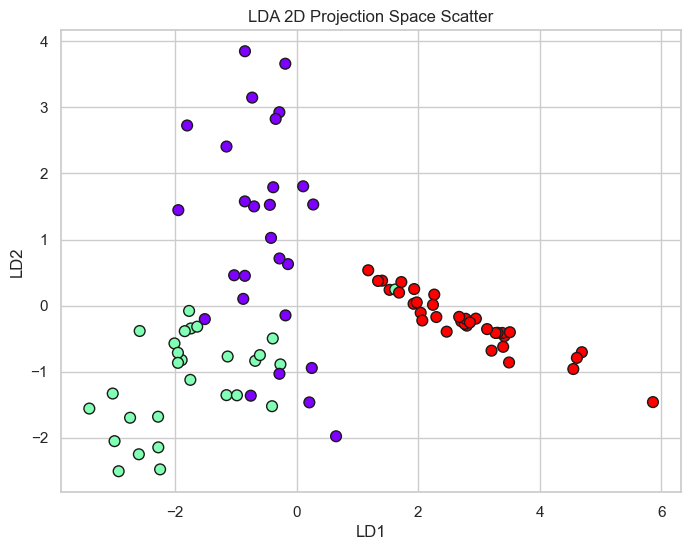

In [10]:
# Visualizing LDA projections
X_test_lda = model.transform(X_test)
plt.figure(figsize=(8, 6))
plt.scatter(X_test_lda[:, 0], X_test_lda[:, 1], c=y_test, cmap='rainbow', edgecolors='k', s=60)
plt.title("LDA 2D Projection Space Scatter")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()

## 13. Save and Load Model

Serialize the model to disk via joblib.

In [11]:
joblib.dump(model, 'model.joblib')
loaded = joblib.load('model.joblib')
print('Loaded successfully!')

Loaded successfully!


## 14. Common Mistakes & Best Practices
- Forgetting to apply the fitted scaler to new evaluation data points, leading to prediction errors.
- Overfitting simple models with excessive features or polynomial terms.

## 15. Advantages
- Fast and easy to interpret baseline results.
- Requires minimal parameter tuning compared to deep neural networks.

## 16. Limitations
- Assumes linear or simple spatial patterns that do not always match real-world anomalies.
- Sensitive to noisy labels and extreme outliers.

## 17. Real-World Applications
- Predicting housing market price trends based on space features.
- Classifying credit card transactions as fraudulent vs benign.

## 18. Algorithm-Specific Interview Questions & Answers
**Q1: What is the difference between PCA and LDA?**

*A: PCA is unsupervised (ignores class labels and maximizes total variance). LDA is supervised (uses labels to maximize between-class variance while minimizing within-class variance).*

**Q2: What is the maximum number of components LDA can output?**

*A: Minimum of (Number of Features, Number of Classes - 1). For 3 classes, LDA can output at most 2 dimensions.*

**Q3: What are the assumptions of LDA?**

*A: Normality of feature distributions, equal covariance matrices across all classes (homoscedasticity), and independence of sample observations.*



## 19. Algorithm-Specific Viva Voce Questions & Answers
**Q1: Define LDA.**

*A: Linear Discriminant Analysis: a supervised method that projects data to maximize class separability.*

**Q2: What does Between-Class Scatter represent?**

*A: The variance between the mean coordinate points of different target classes.*

**Q3: What does Within-Class Scatter represent?**

*A: The variance of data points around their respective class centroids.*



## 20. Practice Exercises
1. **Hyperparameter sweep**: Modify model parameters (such as `max_depth` or neighbor count `K`) and plot the test metric variance curve.
2. **Manual metric calculation**: Compute precision and recall scores manually from the confusion matrix values and verify results using scikit-learn.
3. **Outlier test**: Add an extreme value row to the dataset, re-train, and record the boundary displacement shift.

## 21. Conclusion

In this notebook, we implemented the complete modeling cycle: generating datasets, performing scaling, training the model, evaluating predictions with multiple metrics, saving outputs, and studying typical interview Q&A profiles.